# 021 — Training (heteroscedastic / NLL)

Train `attention_unet_nll` — the heteroscedastic pilot described in `code-review.md` §7.6 — on the RGB → IR translation task.
Instead of a single deterministic value per pixel, the model predicts a mean `mu` and a log-variance `log_var`, trained with the Gaussian negative-log-likelihood loss (`scripts.losses.gaussian_nll_loss`).

This notebook mirrors `020_training.ipynb` but is entirely separate: it does not modify or retrain `unet`, `resunet`, `attention_unet`, or `efficientnet_unet` — their checkpoints are untouched.

Checkpoint saved to `models/attention_unet_nll/best_model.keras`.
Logs written to `logs/attention_unet_nll/` for TensorBoard.

In [1]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

In [2]:
import matplotlib.pyplot as plt
import tensorflow as tf

from scripts.config import settings
from scripts.dataset import (
    build_dataset,
    grouped_train_val_test_split,
    load_image_pairs,
    mockup_aware_train_val_test_split,
)
from scripts.reproducibility import set_global_seed
from scripts.trainer_nll import compile_model_nll, get_callbacks, get_model_nll
from scripts.visualization import plot_training_curves

# Seed Python / NumPy / TensorFlow from settings.SEED for reproducible runs.
set_global_seed()

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")
print(f"TensorFlow version: {tf.__version__}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version: 2.16.2


## 1. Build datasets

In [ ]:
# Artworks split logic: every artwork ID (including the paint-on-support
# mockup groups) is a group kept entirely within a single fold, to prevent
# leakage between sections of the same painting. This can hold an entire
# mockup group out of training even though those groups exist to aid it.
pairs = load_image_pairs(settings.IR_DIR, settings.RGB_DIR)
train_pairs, val_pairs, _ = grouped_train_val_test_split(
    pairs,
    train_ratio= settings.TRAIN_RATIO,
    val_ratio= settings.VAL_RATIO,
    seed=settings.SEED,
)

# crop_size only affects the augmented training split; val stays full-image.
train_ds = build_dataset(
    train_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=True,
    shuffle=True,
    seed=settings.SEED,
    crop_size=settings.CROP_SIZE,
)
val_ds = build_dataset(
    val_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=False,
    shuffle=False,
)

print(f"Train: {len(train_pairs)} patches ({len(train_ds)} batches)")
print(f"Val:   {len(val_pairs)} patches ({len(val_ds)} batches)")

In [3]:
# Artwork and mockups split logic (active): real artworks are still
# grouped and leakage-free, but the mockup groups in
# settings.MOCKUP_ARTWORK_IDS are split at the individual pair level, with
# only a small fraction (default 5%) held out for test — the rest is
# available for train/val. Overwrites train_pairs/val_pairs from the block
# above — this is the split the checkpoints in this notebook are trained
# with, matching 020_training.ipynb's active split.
pairs_mockups = load_image_pairs(settings.IR_DIR, settings.RGB_DIR)
train_pairs, val_pairs, _ = mockup_aware_train_val_test_split(
    pairs_mockups,
    train_ratio=settings.TRAIN_RATIO,
    val_ratio=settings.VAL_RATIO,
    mockup_ids=settings.MOCKUP_ARTWORK_IDS,
    seed=settings.SEED,
)

train_ds = build_dataset(
    train_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=True,
    shuffle=True,
    seed=settings.SEED,
    crop_size=settings.CROP_SIZE,
)
val_ds = build_dataset(
    val_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=False,
    shuffle=False,
)

print(f"Train: {len(train_pairs)} patches ({len(train_ds)} batches)")
print(f"Val:   {len(val_pairs)} patches ({len(val_ds)} batches)")

Train: 863 patches (108 batches)
Val:   166 patches (21 batches)


2026-08-11 12:09:50.971428: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-11 12:09:50.971450: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-11 12:09:50.971455: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-11 12:09:50.971467: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-11 12:09:50.971476: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## 2. Loss function

`attention_unet_nll` outputs two channels per pixel — `mu` (mean, same role as the deterministic models' single output) and `log_var` (log-variance, clipped to `[settings.NLL_LOG_VAR_MIN, settings.NLL_LOG_VAR_MAX]`) — trained with the Gaussian negative-log-likelihood:

```
loss = 0.5 * exp(-log_var) * (y_true - mu) ** 2 + 0.5 * log_var
```

The first term is an uncertainty-weighted squared error; the second penalises inflating `log_var` to trivially shrink the first. See `code-review.md` §7.6 for the full rationale and references (Nix & Weigend 1994; Kendall & Gal 2017; Seitzer et al. 2022).

Metrics (`mae`, `ssim`, `psnr`) are computed from the `mu` channel only (`scripts.metrics.Mu*Metric`), so they stay directly comparable to the deterministic architectures' metrics in `030_evaluation.ipynb`.

## 3. Train `attention_unet_nll`

Set `EPOCHS = 2` for a quick smoke test before committing to a full run.

In [4]:
ARCH = "attention_unet_nll"
EPOCHS = settings.EPOCHS  # -- lower for a quick smoke test

model = get_model_nll(ARCH)
model = compile_model_nll(model, lr=settings.LEARNING_RATE)
model.summary(line_length=80)

callbacks = get_callbacks(
    ARCH,
    log_dir=settings.LOGS_DIR,
    model_dir=settings.MODELS_DIR,
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

best_val_loss = min(history.history["val_loss"])
print(f"\nBest val_loss ({ARCH}): {best_val_loss:.4f}")

Model: "attention_unet_nll"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer           │ (None, None,      │           0 │ -                  │
│ (InputLayer)          │ None, 3)          │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d (Conv2D)       │ (None, None,      │       1,728 │ input_layer[0][0]  │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization   │ (None, None,      │         256 │ conv2d[0][0]       │
│ (BatchNormalization)  │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu (ReLU)          │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_1 (Conv2D)     │ (None, None,      │      36,864 │ re_lu[0][0]        │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_1 │ (None, None,      │         256 │ conv2d_1[0][0]     │
│ (BatchNormalization)  │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_1 (ReLU)        │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ max_pooling2d         │ (None, None,      │           0 │ re_lu_1[0][0]      │
│ (MaxPooling2D)        │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_2 (Conv2D)     │ (None, None,      │      73,728 │ max_pooling2d[0][… │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_2 │ (None, None,      │         512 │ conv2d_2[0][0]     │
│ (BatchNormalization)  │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_2 (ReLU)        │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_3 (Conv2D)     │ (None, None,      │     147,456 │ re_lu_2[0][0]      │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_3 │ (None, None,      │         512 │ conv2d_3[0][0]     │
│ (BatchNormalization)  │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_3 (ReLU)        │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ max_pooling2d_1       │ (None, None,      │           0 │ re_lu_3[0][0]      │
│ (MaxPooling2D)        │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_4 (Conv2D)     │ (None, None,      │     294,912 │ max_pooling2d_1[0… │
│                       │ None,

 Total params: 31,398,114 (119.77 MB)

 Trainable params: 31,386,338 (119.73 MB)

 Non-trainable params: 11,776 (46.00 KB)

Epoch 1/100


/opt/miniconda3/envs/deep-layers/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-08-11 12:10:13.357361: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 939ms/step - loss: -0.7030 - mae: 0.1527 - psnr: 16.0483 - ssim: 0.3059
Epoch 1: val_loss improved from None to -0.41995, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/attention_unet_nll/best_model.keras

Epoch 1: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/attention_unet_nll/best_model.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - loss: -0.7030 - mae: 0.1527 - psnr: 16.0483 - ssim: 0.3059 - val_loss: -0.4199 - val_mae: 0.2140 - val_psnr: 13.6415 - val_ssim: 0.5413 - learning_rate: 1.0000e-04
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 935ms/step - loss: -1.0801 - mae: 0.1422 - psnr: 17.0513 - ssim: 0.5021
Epoch 2: val_loss improved from -0.41995 to -0.92333, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/attention_unet_nll/best_model.keras

Epoch 2: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/attention_unet_nll/best_model.kera

## 4. Training curves

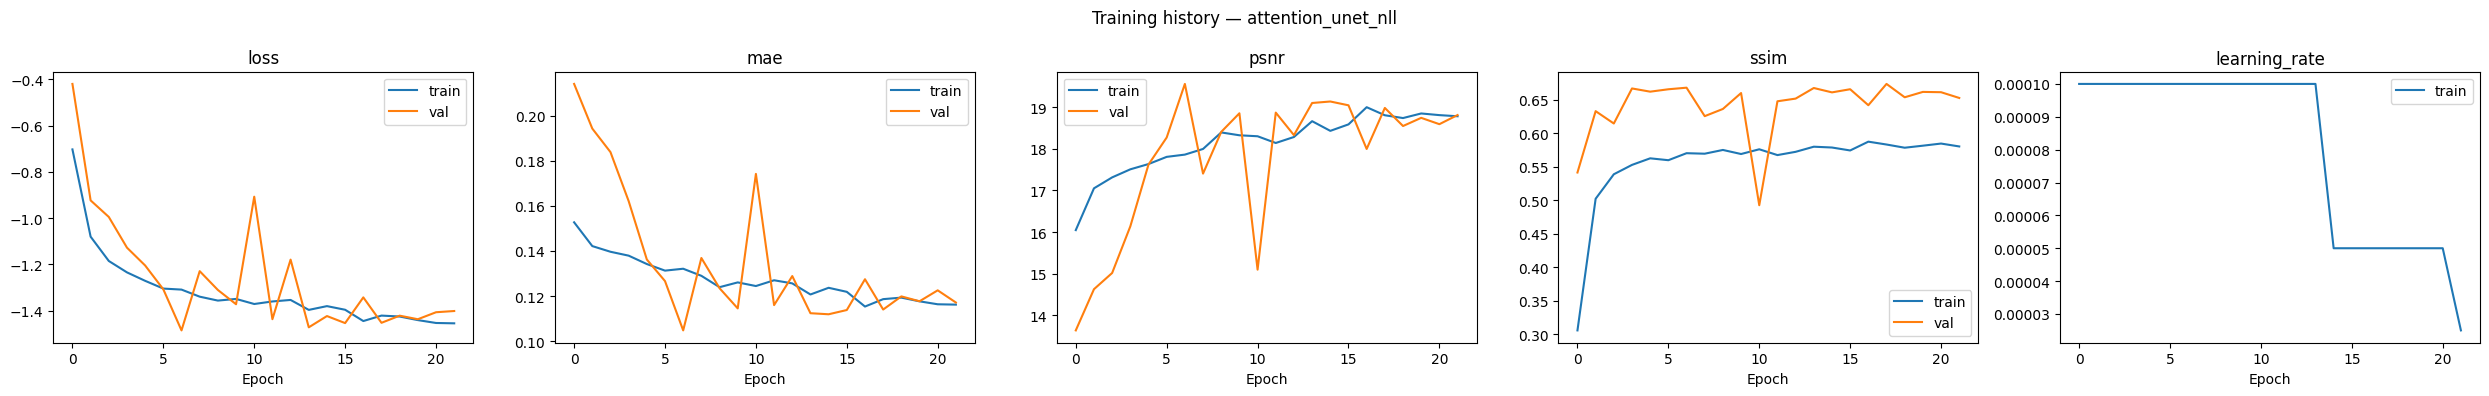

In [5]:
fig = plot_training_curves(history.history, title=f"Training history — {ARCH}")
plt.show()

## 5. Summary

Checkpoint saved to `models/attention_unet_nll/best_model.keras`.  
Run `tensorboard --logdir logs/` to inspect curves interactively.

In [ ]:
ckpt = settings.MODELS_DIR / ARCH / "best_model.keras"
status = "found" if ckpt.exists() else "MISSING"
print(f"{ARCH:<25}: {status}  ({ckpt})")